<a href="https://colab.research.google.com/github/manfredialdo/iad-tpi01/blob/main/TPI_2C_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 0. Datos de identificación

- **Apellido y nombre:** manfredi aldo dario
- **Comisión:** 10
- **Dataset asignado:** hotel booking TPI grupo J.csv
- **Entrega:** Trabajo practico integrador primera entrega
- **Fecha:** 23 de agosto 2026
- **Repositorio:** https://github.com/manfredialdo/iad-tpi01

# Trabajo Práctico Integrador - Introducción al Análisis de Datos

**Caso:** análisis y predicción de cancelaciones en reservas hoteleras.

> Esta plantilla está pensada para construir notebooks independientes y reproducibles. Cada entrega debe poder ejecutarse desde cero, cargando nuevamente el dataset original asignado a la comisión.

**Cátedra:** Introducción al Análisis de Datos — UTN TUPAD

**Objetivo:** Explorar las métricas de tendencia central, dispersión y frecuencias utilizando el dataset real de reservas hoteleras.

**Fecha:** 23/08/2026

### 📌 Buenas Prácticas en Notebooks:
 1. **Ejecución Cronológica:** Ejecuta las celdas de arriba hacia abajo para mantener la memoria limpia.
2. **Modularización:** Una función/propósito por celda.
 3. **Narrativa + Código:** El código calcula, el texto interpreta.


## 1. Importación de librerías

Importar solamente las librerías necesarias para la entrega que se está desarrollando.

In [18]:
# 1. Importación de librerías esenciales
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid") # Configuración visual limpia para los gráficos
print("✅ Librerías cargadas correctamente.")

✅ Librerías cargadas correctamente.


##  2 - Carga del Dataset y Reconocimiento General
Antes de calcular cualquier promedio o porcentaje, la regla de oro del analista es entender la estructura básica del dataset:
* ¿Cuántos registros (filas) y variables (columnas) tenemos?
* ¿Qué tipo de variable es cada una según nuestro **Diccionario de Variables**?

In [23]:
# Carga del archivo CSV
url = "https://raw.githubusercontent.com/manfredialdo/iad-tpi01/refs/heads/main/hotel%20booking%20TPI%20grupo%20J.csv"
df = pd.read_csv(url)

## 3. Presentación breve del problema

Vamos a intentar ver porque hay tantas reservas canceladas, si obedecen a un patron..

A partir de la variable is_cancelled vamos a intentar contestar...
¿que mes del año se trabaja mas?
¿el promedio de lo que pagan los huespedes?



**Variable objetivo:** `is_canceled`

- `0`: reserva no cancelada.
- `1`: reserva cancelada.

La variable is_canceled es de tipo Binaria / objetivo Indica si la reserva fue cancelada. 0 = no

cancelada, 1 = cancelada.

Se trata de una variable categorica


In [24]:
# primer reconocimiento

# Mostrar dimensiones
filas, columnas = df.shape
print(f"El dataset contiene {filas} reservas y {columnas} variables.")

df.head(5) # Visualizar las primeras 5 filas
#print(df.info())
#print(df['is_canceled'].describe())


El dataset contiene 25000 reservas y 32 variables.


,booking_id,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,arrival_date,stays_in_weekend_nights,...,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,HB-035978,Resort Hotel,0,261,2025,April,18,30,2025-04-30,2,...,A,0,No Deposit,40.0,NaN,0,Contract,42.95,0,1
1,HB-004892,Resort Hotel,1,85,2024,April,14,7,2024-04-07,0,...,A,0,No Deposit,67.0,NaN,0,Transient-Party,64.00,0,0
2,HB-076102,City Hotel,1,364,2023,October,42,16,2023-10-16,0,...,A,0,Non Refund,6.0,NaN,0,Transient-Party,101.50,0,0
3,HB-102752,City Hotel,0,32,2024,December,49,4,2024-12-04,2,...,D,0,No Deposit,9.0,NaN,0,Transient,114.00,0,0
4,HB-069831,City Hotel,1,126,2025,June,23,7,2025-06-07,0,...,A,0,No Deposit,27.0,NaN,0,Transient,89.10,0,1


In [25]:
df['is_canceled'].describe()

,is_canceled
count,25000.000000
mean,0.370360
std,0.482911
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


RECONOCIMIENTO


count (25000): ¿Cuántos registros no nulos hay en la columna?

mean (0.370360): ¿Cuál es el promedio? (En variables de 0 y 1, equivale directamente a la tasa porcentual de cancelación: 37.04%).

std (0.482911): ¿Qué tan dispersos o variados están los datos respecto a la media?

min (0.0): ¿Cuál es el valor mínimo registrado?

25% (0.0): ¿Hasta qué valor llega el primer 25% de los datos ordenados?

50% (0.0): ¿Cuál es la mediana (el valor que divide la muestra exactamente a la mitad)?

75% (1.0): ¿Hasta qué valor llega el 75% de los datos ordenados?

max (1.0): ¿Cuál es el valor máximo registrado?

In [26]:
# Comprobar la cantidad de filas canceladas (1) y no canceladas (0)
print("Frecuencia absoluta:")
print(df["is_canceled"].value_counts())

# Tasa porcentual de cancelación
print("\nTasa de cancelación (%):")
print(df["is_canceled"].value_counts(normalize=True) * 100)

Frecuencia absoluta:
is_canceled
0    15741
1     9259
Name: count, dtype: int64

Tasa de cancelación (%):
is_canceled
0    62.964
1    37.036
Name: proportion, dtype: float64


RECONOCIMIENTO

In [14]:
# Resumen completo de la variable is_canceled
s = df['is_canceled']

print(f"Tipo de dato: {s.dtype}")
print(f"Valores nulos: {s.isna().sum()}")
print(f"Valores únicos: {s.unique()}")
print(f"Total de la muestra: {s.count():,}")
print(f"Cuántas cancelaciones hubo: {s.sum():,}")
print(f"Tasa de cancelación (Media): {s.mean():.4f} ({s.mean()*100:.2f}%)")
print(f"Moda (Valor más frecuente): {s.mode()[0]}")

Tipo de dato: int64
Valores nulos: 0
Valores únicos: [0 1]
Total de la muestra: 25,000
Cuántas cancelaciones hubo: 9,259
Tasa de cancelación (Media): 0.3704 (37.04%)
Moda (Valor más frecuente): 0


de un total de 25000 reservas hubo 9259 cancelaciones, es decir hubo un 37,04% de cancelaciones..

Esto representa un problema para la empresa... hay algo para mejorar?

##  -  Variables Categóricas: Fr. Absolutas y Relativas
Las frecuencias organizan variables cualitativas o binarias.
Veamos qué pasa con **`is_canceled`**

($0 =$ Reserva Efectiva, $1 =$ Reserva Cancelada):
* **Frecuencia Absoluta:** Conteo puro de reservas.
* **Frecuencia Relativa:** Porcentaje respecto al total (evita engaños por volumen).

                  Cantidad de Reservas  Porcentaje (%)
No Cancelada (0)                 15741           62.96
Cancelada (1)                     9259           37.04


<Axes: xlabel='is_canceled', ylabel='count'>

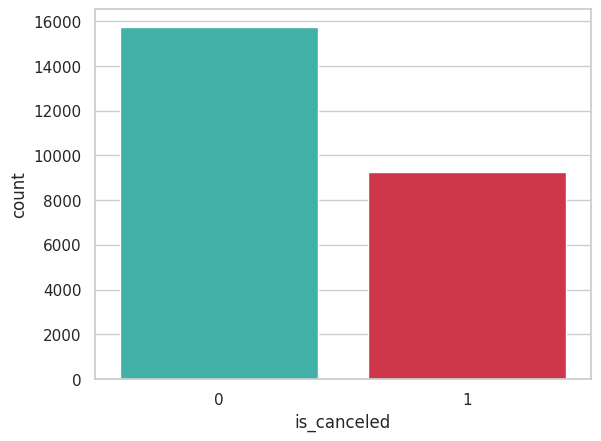

In [15]:
# Cálculo de frecuencias para cancelaciones
frec_absoluta = df['is_canceled'].value_counts()
frec_relativa = df['is_canceled'].value_counts(normalize=True) * 100

# Crear una tabla resumen
tabla_cancelaciones = pd.DataFrame({
    'Cantidad de Reservas': frec_absoluta,
    'Porcentaje (%)': frec_relativa.round(2)
})
tabla_cancelaciones.index = ['No Cancelada (0)', 'Cancelada (1)']
print(tabla_cancelaciones)

sns.countplot(data=df, x='is_canceled', hue='is_canceled', palette=['#2ec4b6', '#e71d36'], legend=False)

                  Cantidad de Reservas  Porcentaje (%)
No Cancelada (0)                 15741           62.96
Cancelada (1)                     9259           37.04


/tmp/ipykernel_3195/137564066.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='is_canceled', palette=['#2ec4b6', '#e71d36'])


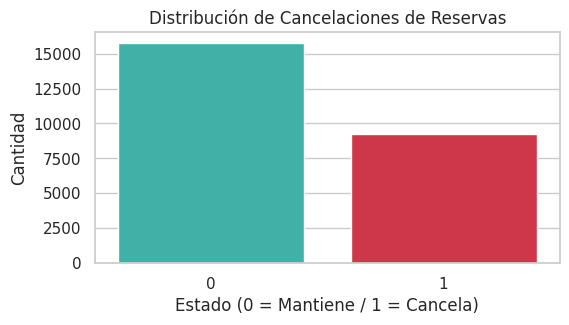

In [19]:
# Cálculo de frecuencias para cancelaciones
frec_absoluta = df['is_canceled'].value_counts()
frec_relativa = df['is_canceled'].value_counts(normalize=True) * 100

# Crear una tabla resumen
tabla_cancelaciones = pd.DataFrame({
    'Cantidad de Reservas': frec_absoluta,
    'Porcentaje (%)': frec_relativa.round(2)
})
tabla_cancelaciones.index = ['No Cancelada (0)', 'Cancelada (1)']
print(tabla_cancelaciones)

# Gráfico de Barras Simple
plt.figure(figsize=(6, 3))
sns.countplot(data=df, x='is_canceled', palette=['#2ec4b6', '#e71d36'])
plt.title('Distribución de Cancelaciones de Reservas')
plt.xlabel('Estado (0 = Mantiene / 1 = Cancela)')
plt.ylabel('Cantidad')
plt.show()

In [21]:
df['is_canceled'].value_counts()

,count
is_canceled,
0,15741
1,9259


mas de un tercio de las reservas son canceladas

<Axes: title={'center': 'Distribución de Cancelaciones'}>

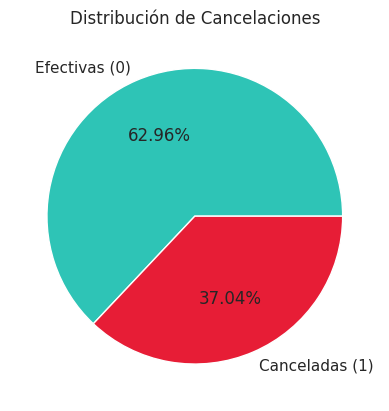

In [20]:
df['is_canceled'].value_counts().plot.pie(autopct='%1.2f%%', colors=['#2ec4b6', '#e71d36'], labels=['Efectivas (0)', 'Canceladas (1)'], title='Distribución de Cancelaciones', ylabel='')

<Axes: title={'center': 'Distribución de Cancelaciones'}>

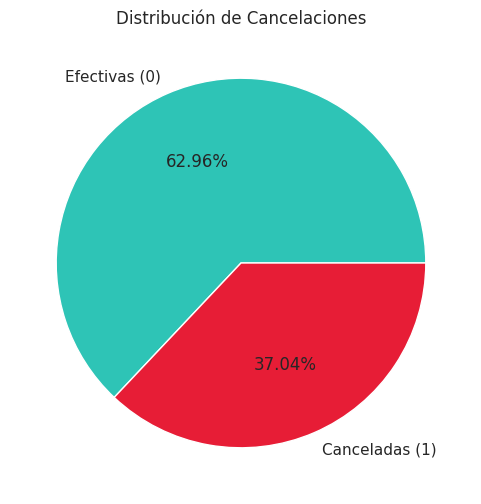

In [22]:
df['is_canceled'].value_counts().sort_index().plot.pie(
    autopct='%1.2f%%',
    colors=['#2ec4b6', '#e71d36'],
    labels=['Efectivas (0)', 'Canceladas (1)'],
    title='Distribución de Cancelaciones',
    ylabel='',
    figsize=(6, 6)
)

## 4. Preparación mínima reproducible

En cada entrega reconstruir aquí las variables o ajustes necesarios para continuar el análisis. No depender de notebooks anteriores.

## 5. Desarrollo de la entrega

Usar esta sección para desarrollar la consigna correspondiente a la semana. Combinar código, resultados e interpretaciones.

### 5.1 Pregunta o propósito de análisis

Escribir qué se busca analizar en este apartado.

In [ ]:
# Código de análisis


**Interpretación:**

Escribir aquí qué muestra el resultado obtenido y por qué es relevante para el problema de cancelación de reservas.

### 5.2 Desarrollo adicional

Agregar las subsecciones necesarias según la entrega: limpieza, transformación, visualización, EDA, modelado o evaluación.

In [ ]:
# Continuar el desarrollo según corresponda


## 6. Conclusiones parciales

Sintetizar los principales hallazgos de esta entrega.
Indicar qué decisiones se tomaron y qué resultados se obtuvieron.

## 7. Limitaciones y próximos pasos

Reconocer qué aspectos todavía no pueden afirmarse, qué limitaciones tienen los datos o el modelo, y qué consideran que se debería profundizar más adelante.

---

### **Recordatorio**

El TPI no se evalúa solo por ejecutar código. También se evalúa la claridad con la que se justifican decisiones, se interpretan resultados, se reconocen limitaciones y se comunican conclusiones.
Te recomendamos redactar con tus palabras para ir armando la defensa del coloquio final.